In [ ]:
import urllib.request

url = "https://ftp.ebi.ac.uk/pub/databases/chembl/ChEMBLdb/releases/chembl_35/chembl_35_chemreps.txt.gz"

output_file = "chembl_35_chemreps.txt.gz"

print("Downloading ChEMBL chemreps file...")

urllib.request.urlretrieve(url, output_file)

print("Download complete!")

In [ ]:
import gzip
import shutil

gz_file = "chembl_35_chemreps.txt.gz"
out_file = "chembl_35_chemreps.txt"

print("Unzipping...")

with gzip.open(gz_file, "rb") as f_in:
    with open(out_file, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

print("Done:", out_file)

In [ ]:
import pandas as pd

df = pd.read_csv("chembl_35_chemreps.txt", sep="\t")
print(df.head())

In [ ]:
print(df.columns)
print(df.shape)

In [ ]:
df = df[["chembl_id", "canonical_smiles"]]
df = df.dropna()
print(df.head())

In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, Crippen
from tqdm import tqdm

def strict_filter(smiles):

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return False

    mw = Descriptors.MolWt(mol)
    logp = Crippen.MolLogP(mol)
    hbd = Lipinski.NumHDonors(mol)
    hba = Lipinski.NumHAcceptors(mol)
    tpsa = Descriptors.TPSA(mol)
    rotb = Lipinski.NumRotatableBonds(mol)

    # Tight Rules
    if mw < 200 or mw > 450:
        return False
    if logp < 1.0 or logp > 4.0:
        return False
    if hbd > 3:
        return False
    if hba > 8:
        return False
    if tpsa < 20 or tpsa > 120:
        return False
    if rotb > 7:
        return False

    return True

In [ ]:
filtered_hits = []

for i in tqdm(range(0, len(df), 50000)):

    chunk = df.iloc[i:i+50000]

    for _, row in chunk.iterrows():

        cid = row["chembl_id"]
        smi = row["canonical_smiles"]

        if strict_filter(smi):

            filtered_hits.append([cid, smi])

    # Save every 10k hits
    if len(filtered_hits) > 10000:
        temp = pd.DataFrame(filtered_hits, columns=["ChEMBL_ID", "SMILES"])
        temp.to_csv("filtered_hits.csv", mode="a",
                    header=False, index=False)
        filtered_hits = []

print("Drug-like filtering completed!")

In [ ]:
from chembl_webresource_client.new_client import new_client
import pandas as pd
import numpy as np

activity = new_client.activity

# RAS pathway target IDs
targets = {
    "KRAS": "CHEMBL218",
    "HRAS": "CHEMBL252",
    "NRAS": "CHEMBL245",
    "BRAF": "CHEMBL5145",
    "RAF1": "CHEMBL3116",
    "MEK1": "CHEMBL3587"
}

data = []

for name, tid in targets.items():

    print("Downloading:", name)

    acts = activity.filter(
        target_chembl_id=tid,
        standard_type="IC50"
    ).only(["canonical_smiles", "standard_value"])

    for a in acts:
        smi = a["canonical_smiles"]
        val = a["standard_value"]

        if smi and val:
            try:
                ic50 = float(val)
                if ic50 <= 0:
                    continue

                pic50 = 9 - np.log10(ic50)
                active = 1 if pic50 >= 6 else 0

                data.append([smi, active, pic50, name])

            except:
                continue

train_df = pd.DataFrame(
    data, columns=["SMILES", "Active", "pIC50", "Target"]
)

train_df.to_csv("RAS_pathway_training.csv", index=False)

print("\nSaved dataset size:", train_df.shape)

In [1]:
pwd

'C:\\Users\\sakthi'

In [2]:
# ============================================
# Correct RAS Classification Using SMILES Fingerprints
# ============================================

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import AllChem

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

# ============================================
# 1. Load CSV
# ============================================

df = pd.read_csv("RAS_pathway_trainings.csv")

print(df.columns)
print(df["Active"].value_counts())

# ============================================
# 2. Convert SMILES to Morgan Fingerprints
# ============================================

def smiles_to_morgan(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius,
        nBits=n_bits
    )

    arr = np.zeros((n_bits,), dtype=int)
    AllChem.DataStructs.ConvertToNumpyArray(fp, arr)

    return arr

fps = []
valid_index = []

for i, smi in enumerate(df["SMILES"]):
    fp = smiles_to_morgan(smi)

    if fp is not None:
        fps.append(fp)
        valid_index.append(i)

X = np.array(fps)
y_class = df.iloc[valid_index]["Active"].values

print("Fingerprint matrix:", X.shape)
print("Target:", pd.Series(y_class).value_counts())

# ============================================
# 3. Train-test split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

# ============================================
# 4. Models
# ============================================

models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ),

    "GradientBoosting": GradientBoostingClassifier(
        random_state=42
    ),

    "DecisionTree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=3000,
            random_state=42,
            class_weight="balanced"
        ))
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            probability=True,
            random_state=42,
            class_weight="balanced"
        ))
    ])
}

# ============================================
# 5. Training + Results
# ============================================

results = []
roc_data = {}

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

for name, model in models.items():

    print("\nTraining:", name)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc = roc_auc_score(y_test, y_prob)

    cv_scores = cross_val_score(
        model,
        X,
        y_class,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    results.append([
        name, acc, prec, rec, f1, roc,
        cv_scores.mean(), cv_scores.std()
    ])

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data[name] = [fpr, tpr, roc]

    joblib.dump(model, f"{name}_RAS_Morgan_classifier.pkl")

# ============================================
# 6. Save results CSV
# ============================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "10Fold_CV_ROC_AUC_Mean",
        "10Fold_CV_ROC_AUC_SD"
    ]
)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

results_df.to_csv(
    "RAS_Morgan_Classification_Results.csv",
    index=False
)

print(results_df)

Index(['ChEMBL_ID', 'SMILES', 'Active', 'pIC50', 'Target'], dtype='object')
Active
1    16001
0     4066
Name: count, dtype: int64


[18:14:02] DEPRECATION WARNING: please use MorganGenerator
[18:14:02] DEPRECATION WARNING: please use MorganGenerator
[18:14:02] DEPRECATION WARNING: please use MorganGenerator
[18:14:02] DEPRECATION WARNING: please use MorganGenerator
[18:14:02] DEPRECATION WARNING: please use MorganGenerator
[18:14:02] DEPRECATION WARNING: please use MorganGenerator
[18:14:02] DEPRECATION WARNING: please use MorganGenerator
[18:14:02] DEPRECATION WARNING: please use MorganGenerator
[18:14:02] DEPRECATION WARNING: please use MorganGenerator
[18:14:02] DEPRECATION WARNING: please use MorganGenerator
[18:14:02] DEPRECATION WARNING: please use MorganGenerator
[18:14:02] DEPRECATION WARNING: please use MorganGenerator
[18:14:02] DEPRECATION WARNING: please use MorganGenerator
[18:14:02] DEPRECATION WARNING: please use MorganGenerator
[18:14:02] DEPRECATION WARNING: please use MorganGenerator
[18:14:02] DEPRECATION WARNING: please use MorganGenerator
[18:14:02] DEPRECATION WARNING: please use MorganGenerat

Fingerprint matrix: (20067, 2048)
Target: 1    16001
0     4066
Name: count, dtype: int64

Training: RandomForest

Training: GradientBoosting

Training: DecisionTree

Training: LogisticRegression

Training: SVM
                Model  Accuracy  Precision    Recall  F1-score   ROC-AUC  \
0        RandomForest  0.897608   0.931889  0.940331  0.936091  0.934903   
4                 SVM  0.867962   0.942072  0.889097  0.914818  0.914706   
3  LogisticRegression  0.835326   0.929344  0.858794  0.892677  0.866510   
1    GradientBoosting  0.843049   0.843809  0.985629  0.909222  0.858997   
2        DecisionTree  0.861983   0.926798  0.897844  0.912091  0.816124   

   10Fold_CV_ROC_AUC_Mean  10Fold_CV_ROC_AUC_SD  
0                0.939134              0.005952  
4                0.927444              0.005400  
3                0.885607              0.011184  
1                0.875852              0.008241  
2                0.813287              0.012469  


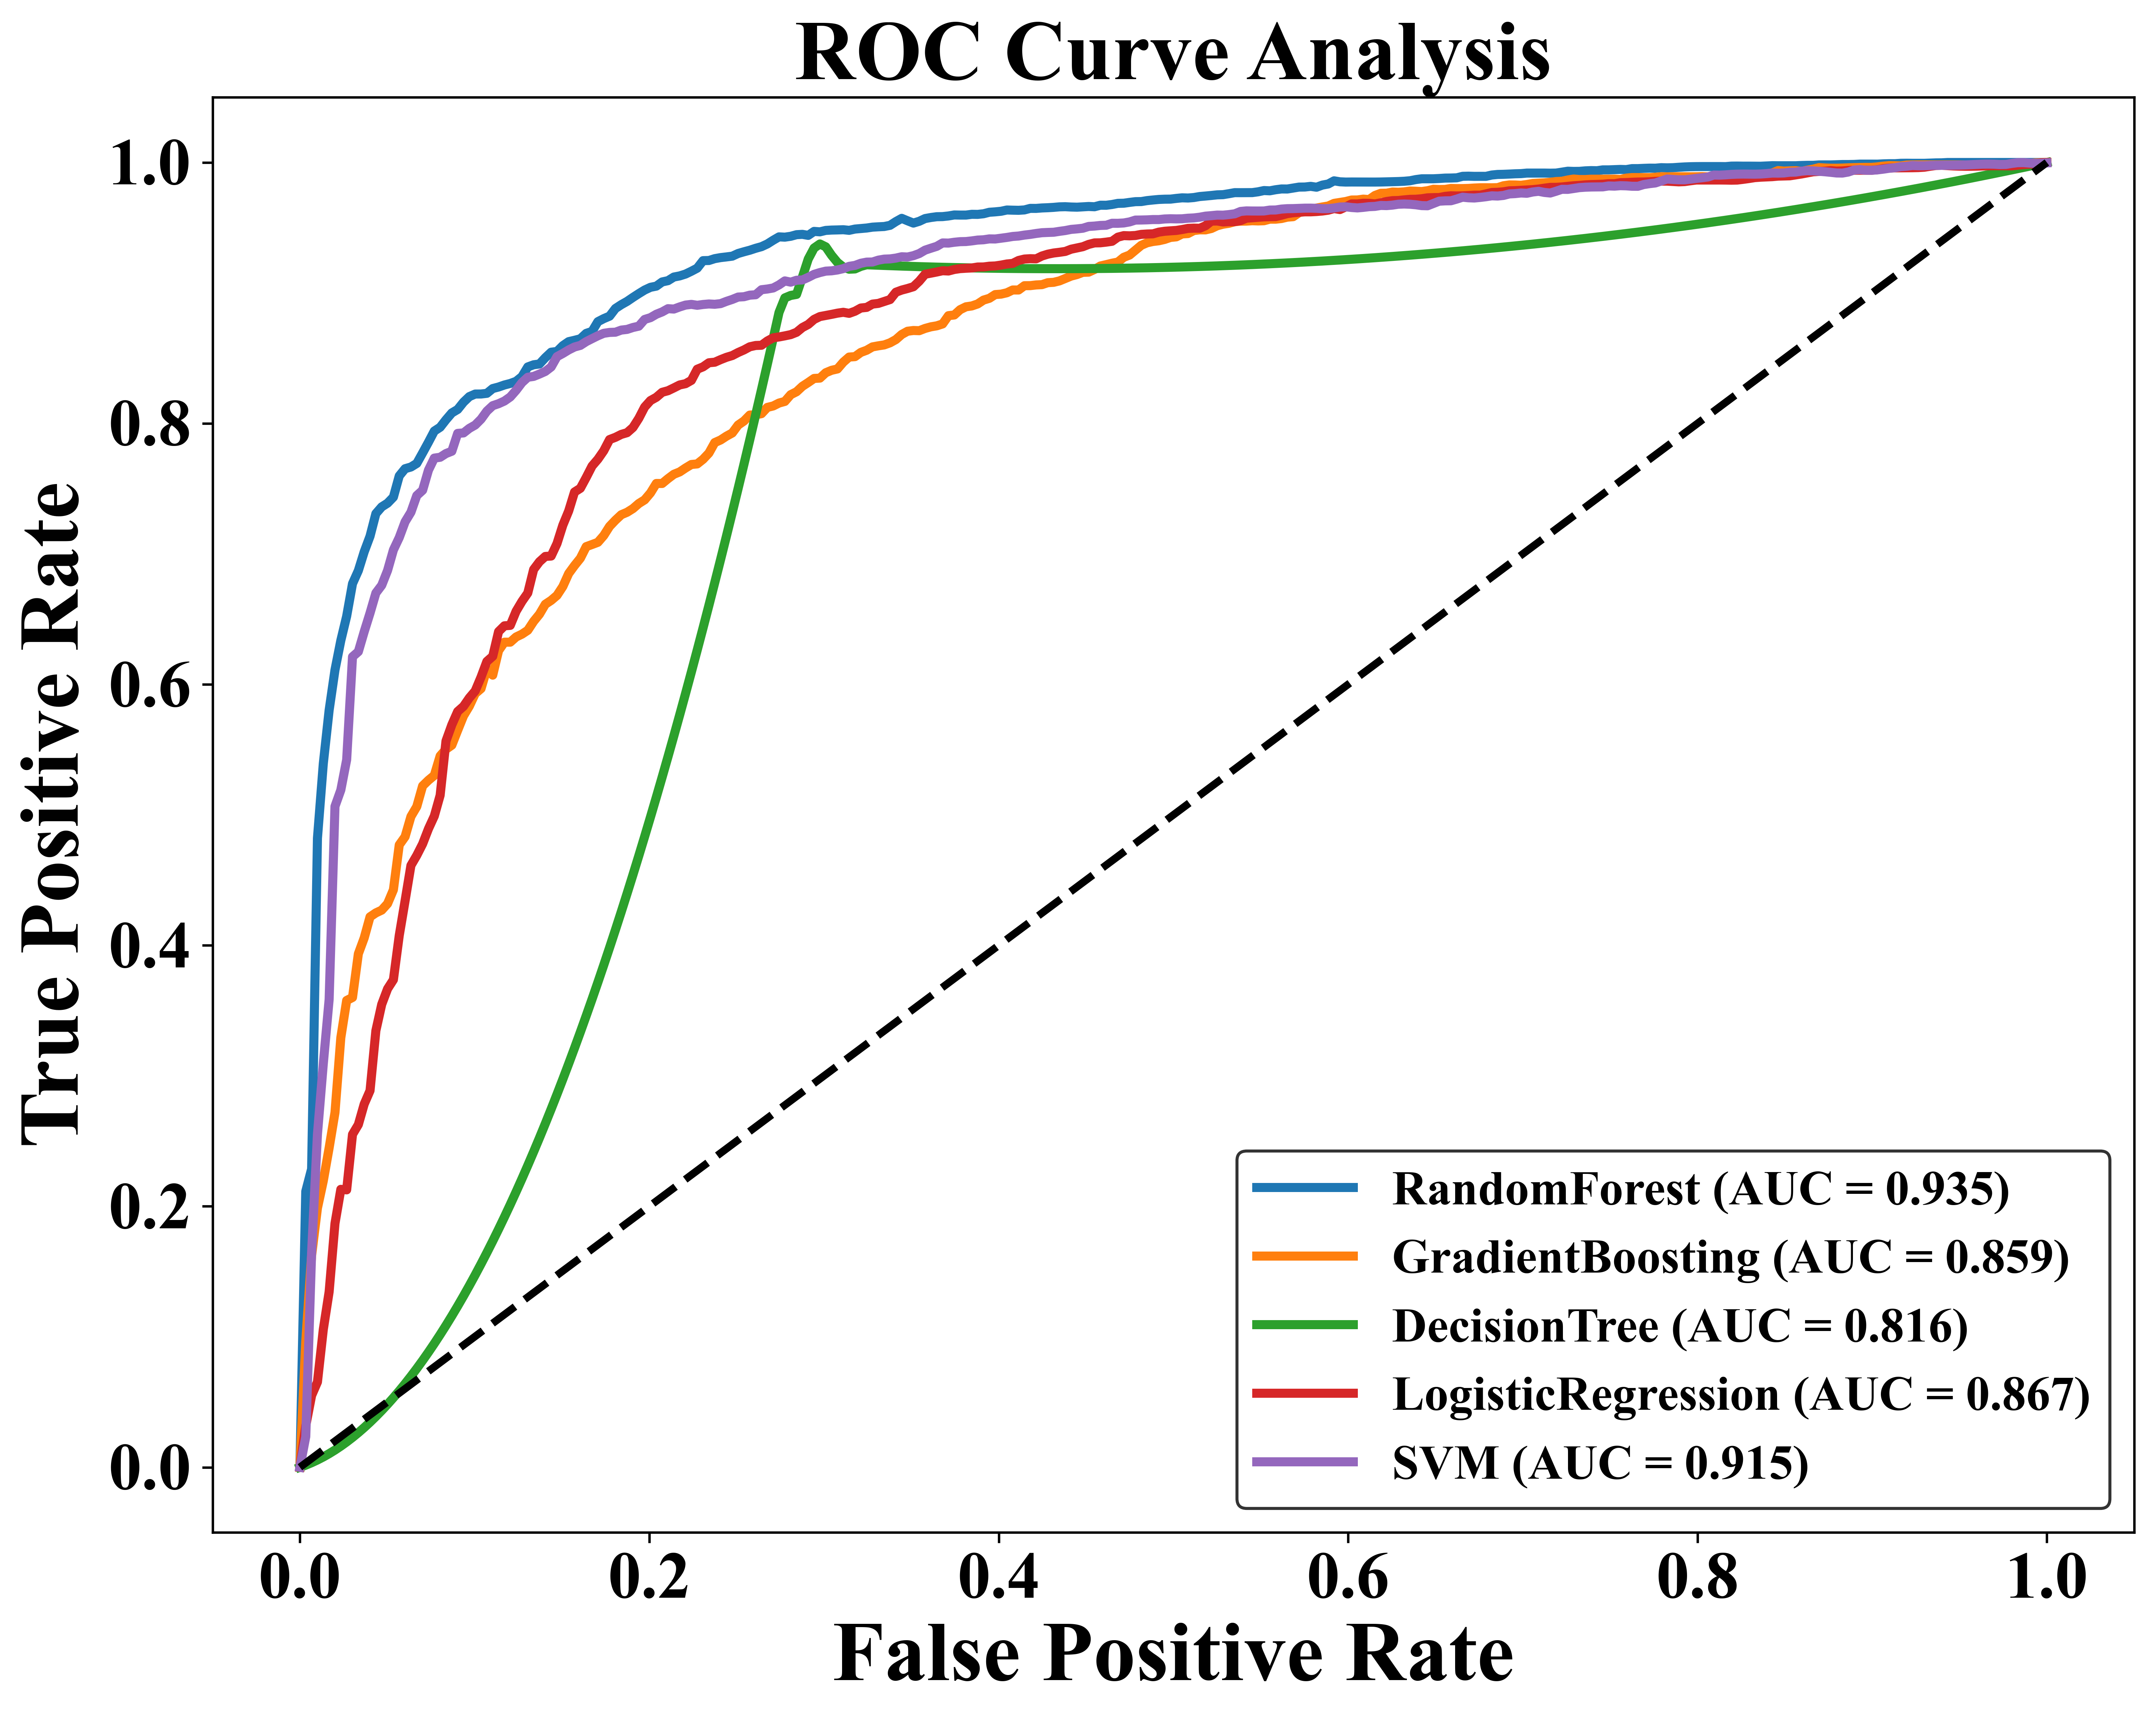

In [3]:
# ============================================
# Smooth Publication ROC Curve
# ============================================

from scipy.interpolate import make_interp_spline
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.weight"] = "bold"

plt.figure(figsize=(10, 8), dpi=600)

for name, values in roc_data.items():
    fpr, tpr, roc_auc = values

    # remove duplicate fpr values
    fpr_unique, index = np.unique(fpr, return_index=True)
    tpr_unique = tpr[index]

    # smooth curve
    x_smooth = np.linspace(fpr_unique.min(), fpr_unique.max(), 300)
    spline = make_interp_spline(fpr_unique, tpr_unique, k=2)
    y_smooth = spline(x_smooth)

    y_smooth = np.clip(y_smooth, 0, 1)

    plt.plot(
        x_smooth,
        y_smooth,
        linewidth=3,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

plt.plot([0, 1], [0, 1], "--", linewidth=2.5, color="black")

plt.xlabel("False Positive Rate", fontsize=28, fontweight="bold")
plt.ylabel("True Positive Rate", fontsize=28, fontweight="bold")
plt.title("ROC Curve Analysis", fontsize=28, fontweight="bold")

plt.xticks(fontsize=22, fontweight="bold")
plt.yticks(fontsize=22, fontweight="bold")

plt.legend(
    fontsize=16,
    loc="lower right",
    frameon=True,
    edgecolor="black"
)

plt.grid(False)
plt.tight_layout()

plt.savefig("Smooth_ROC_Curve.png", dpi=600, bbox_inches="tight")
plt.savefig("Smooth_ROC_Curve.tiff", dpi=600, bbox_inches="tight")
plt.show()

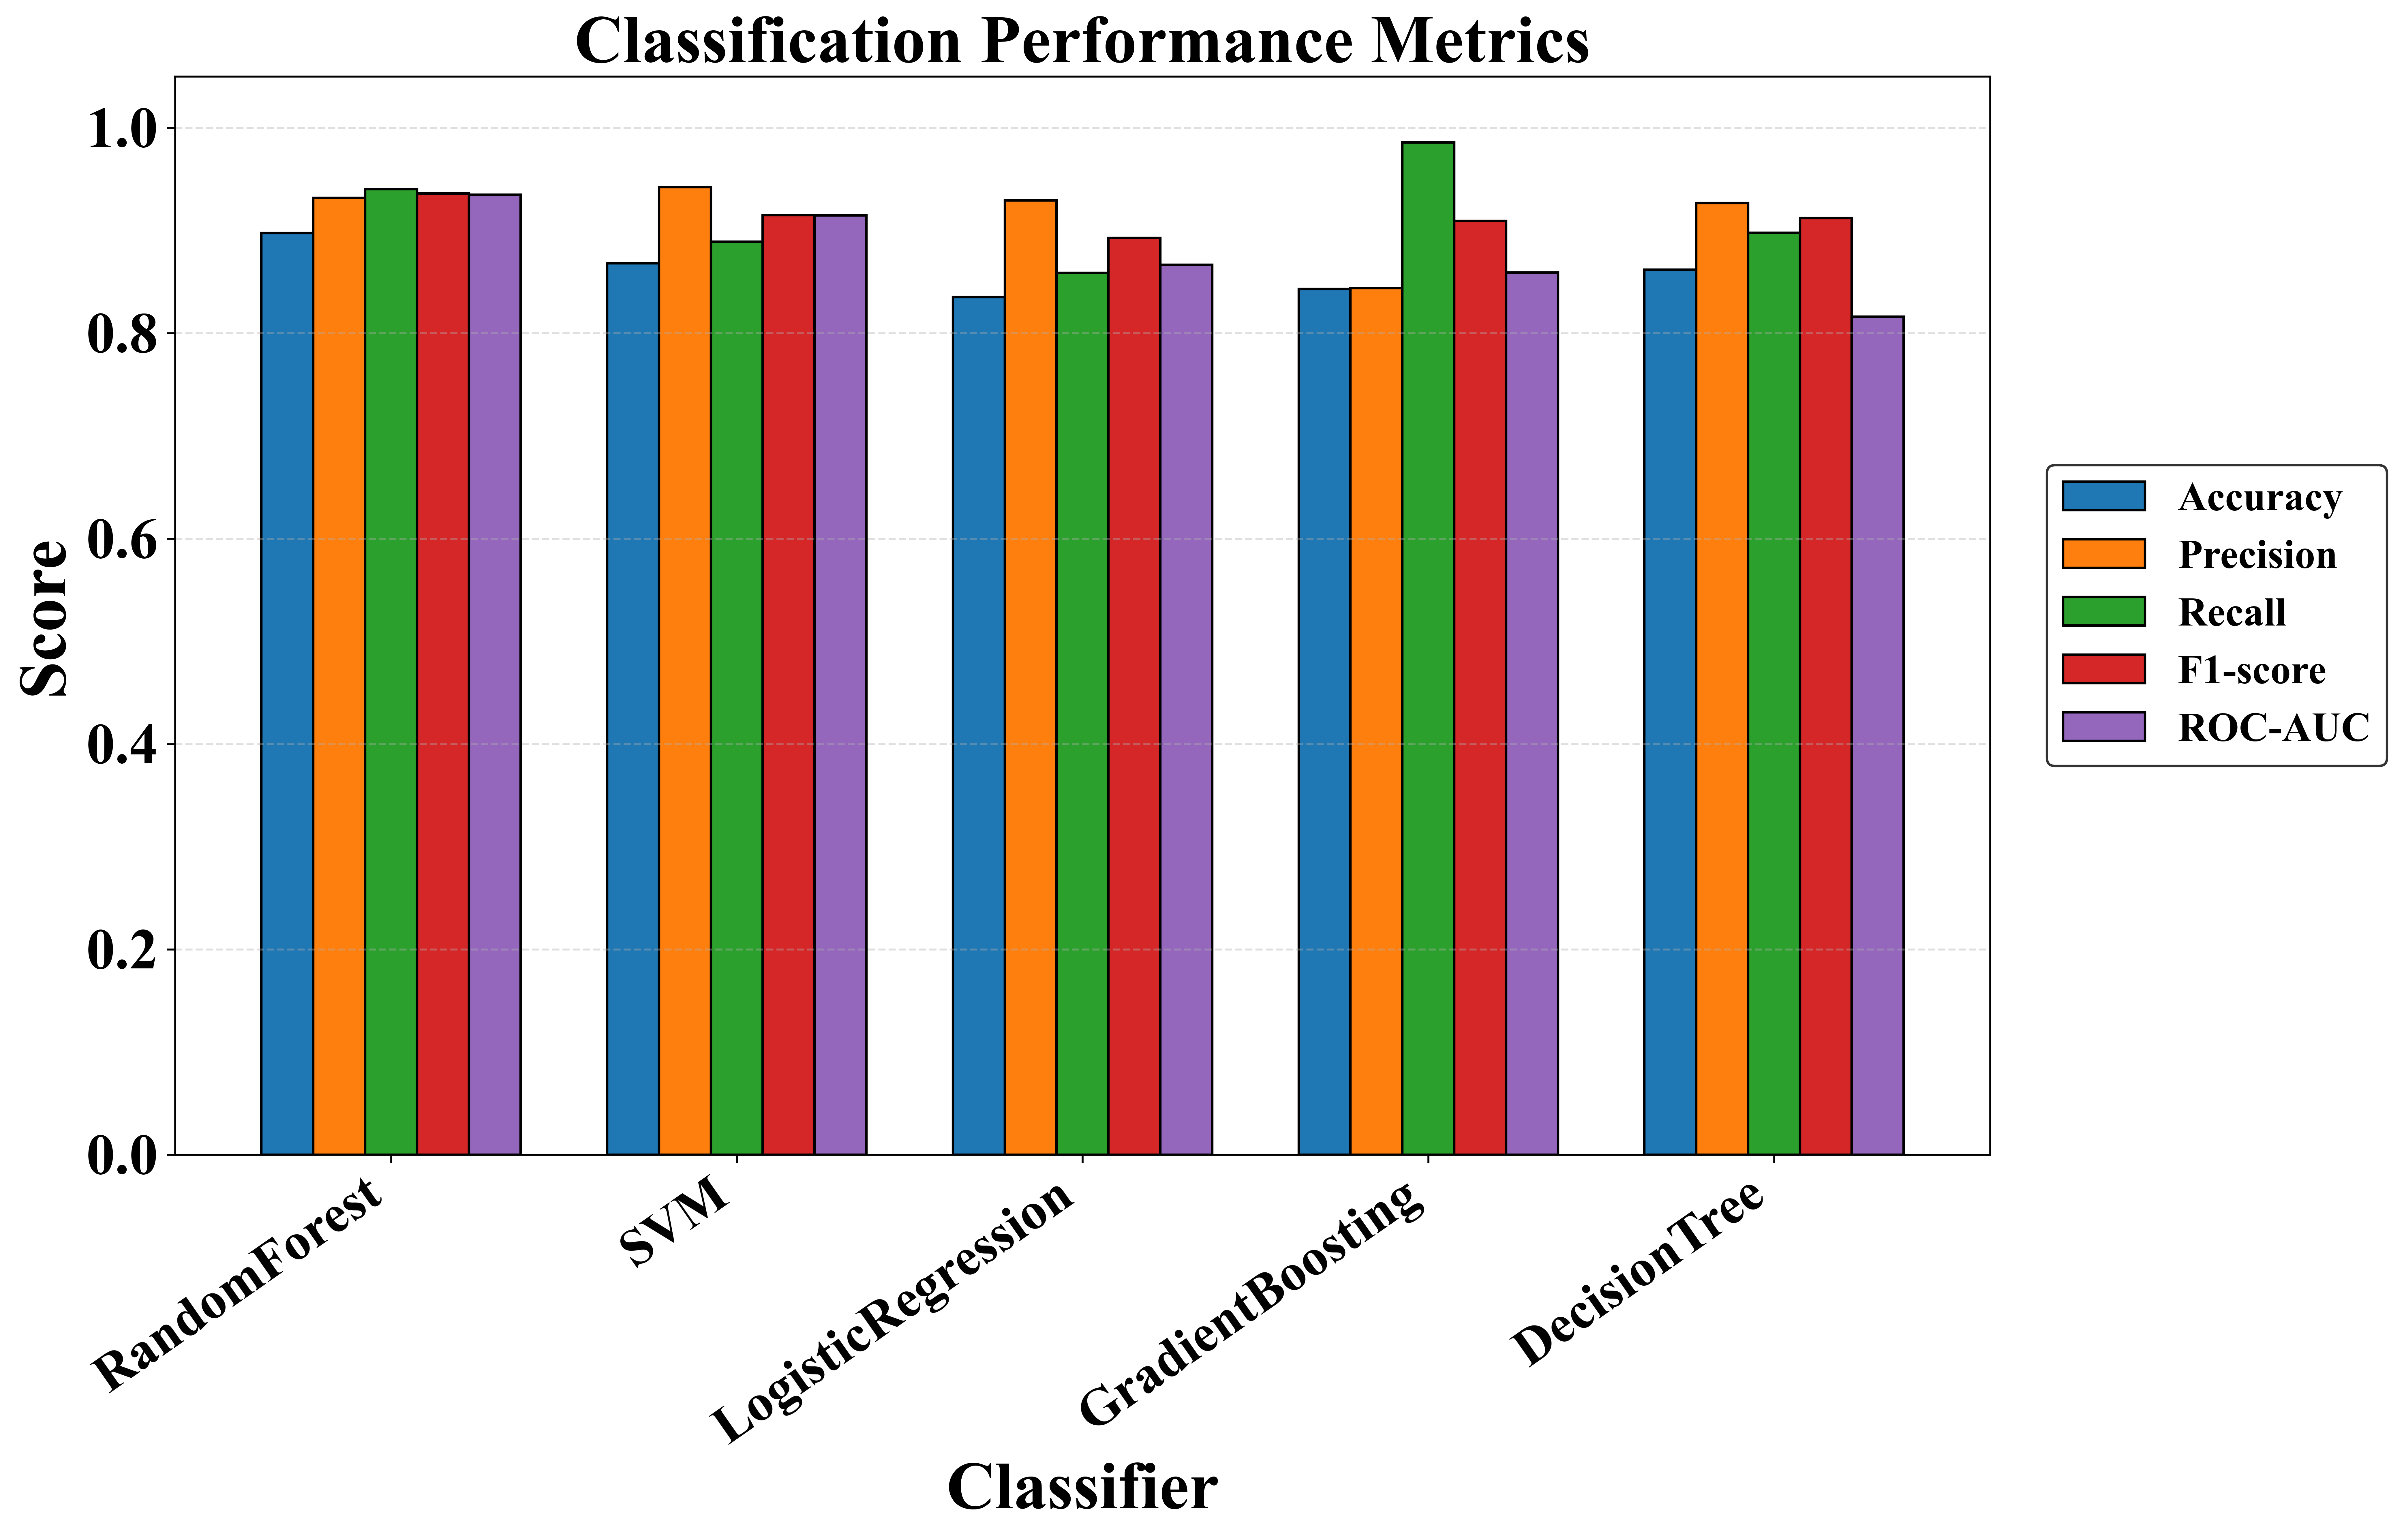

In [4]:
# ============================================
# Corrected Publication Metrics Bar Plot
# ============================================

import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.weight"] = "bold"

metrics_plot = results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
]

fig, ax = plt.subplots(figsize=(14, 9), dpi=600)

metrics_plot.plot(
    kind="bar",
    ax=ax,
    width=0.75,
    edgecolor="black"
)

ax.set_ylabel("Score", fontsize=28, fontweight="bold")
ax.set_xlabel("Classifier", fontsize=28, fontweight="bold")
ax.set_title("Classification Performance Metrics", fontsize=28, fontweight="bold")

ax.set_ylim(0, 1.05)

plt.xticks(rotation=35, ha="right", fontsize=22, fontweight="bold")
plt.yticks(fontsize=24, fontweight="bold")

ax.legend(
    fontsize=17,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    edgecolor="black"
)

ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig("Classification_Metrics_BarPlot.png", dpi=600, bbox_inches="tight")
plt.savefig("Classification_Metrics_BarPlot.tiff", dpi=600, bbox_inches="tight")
plt.show()

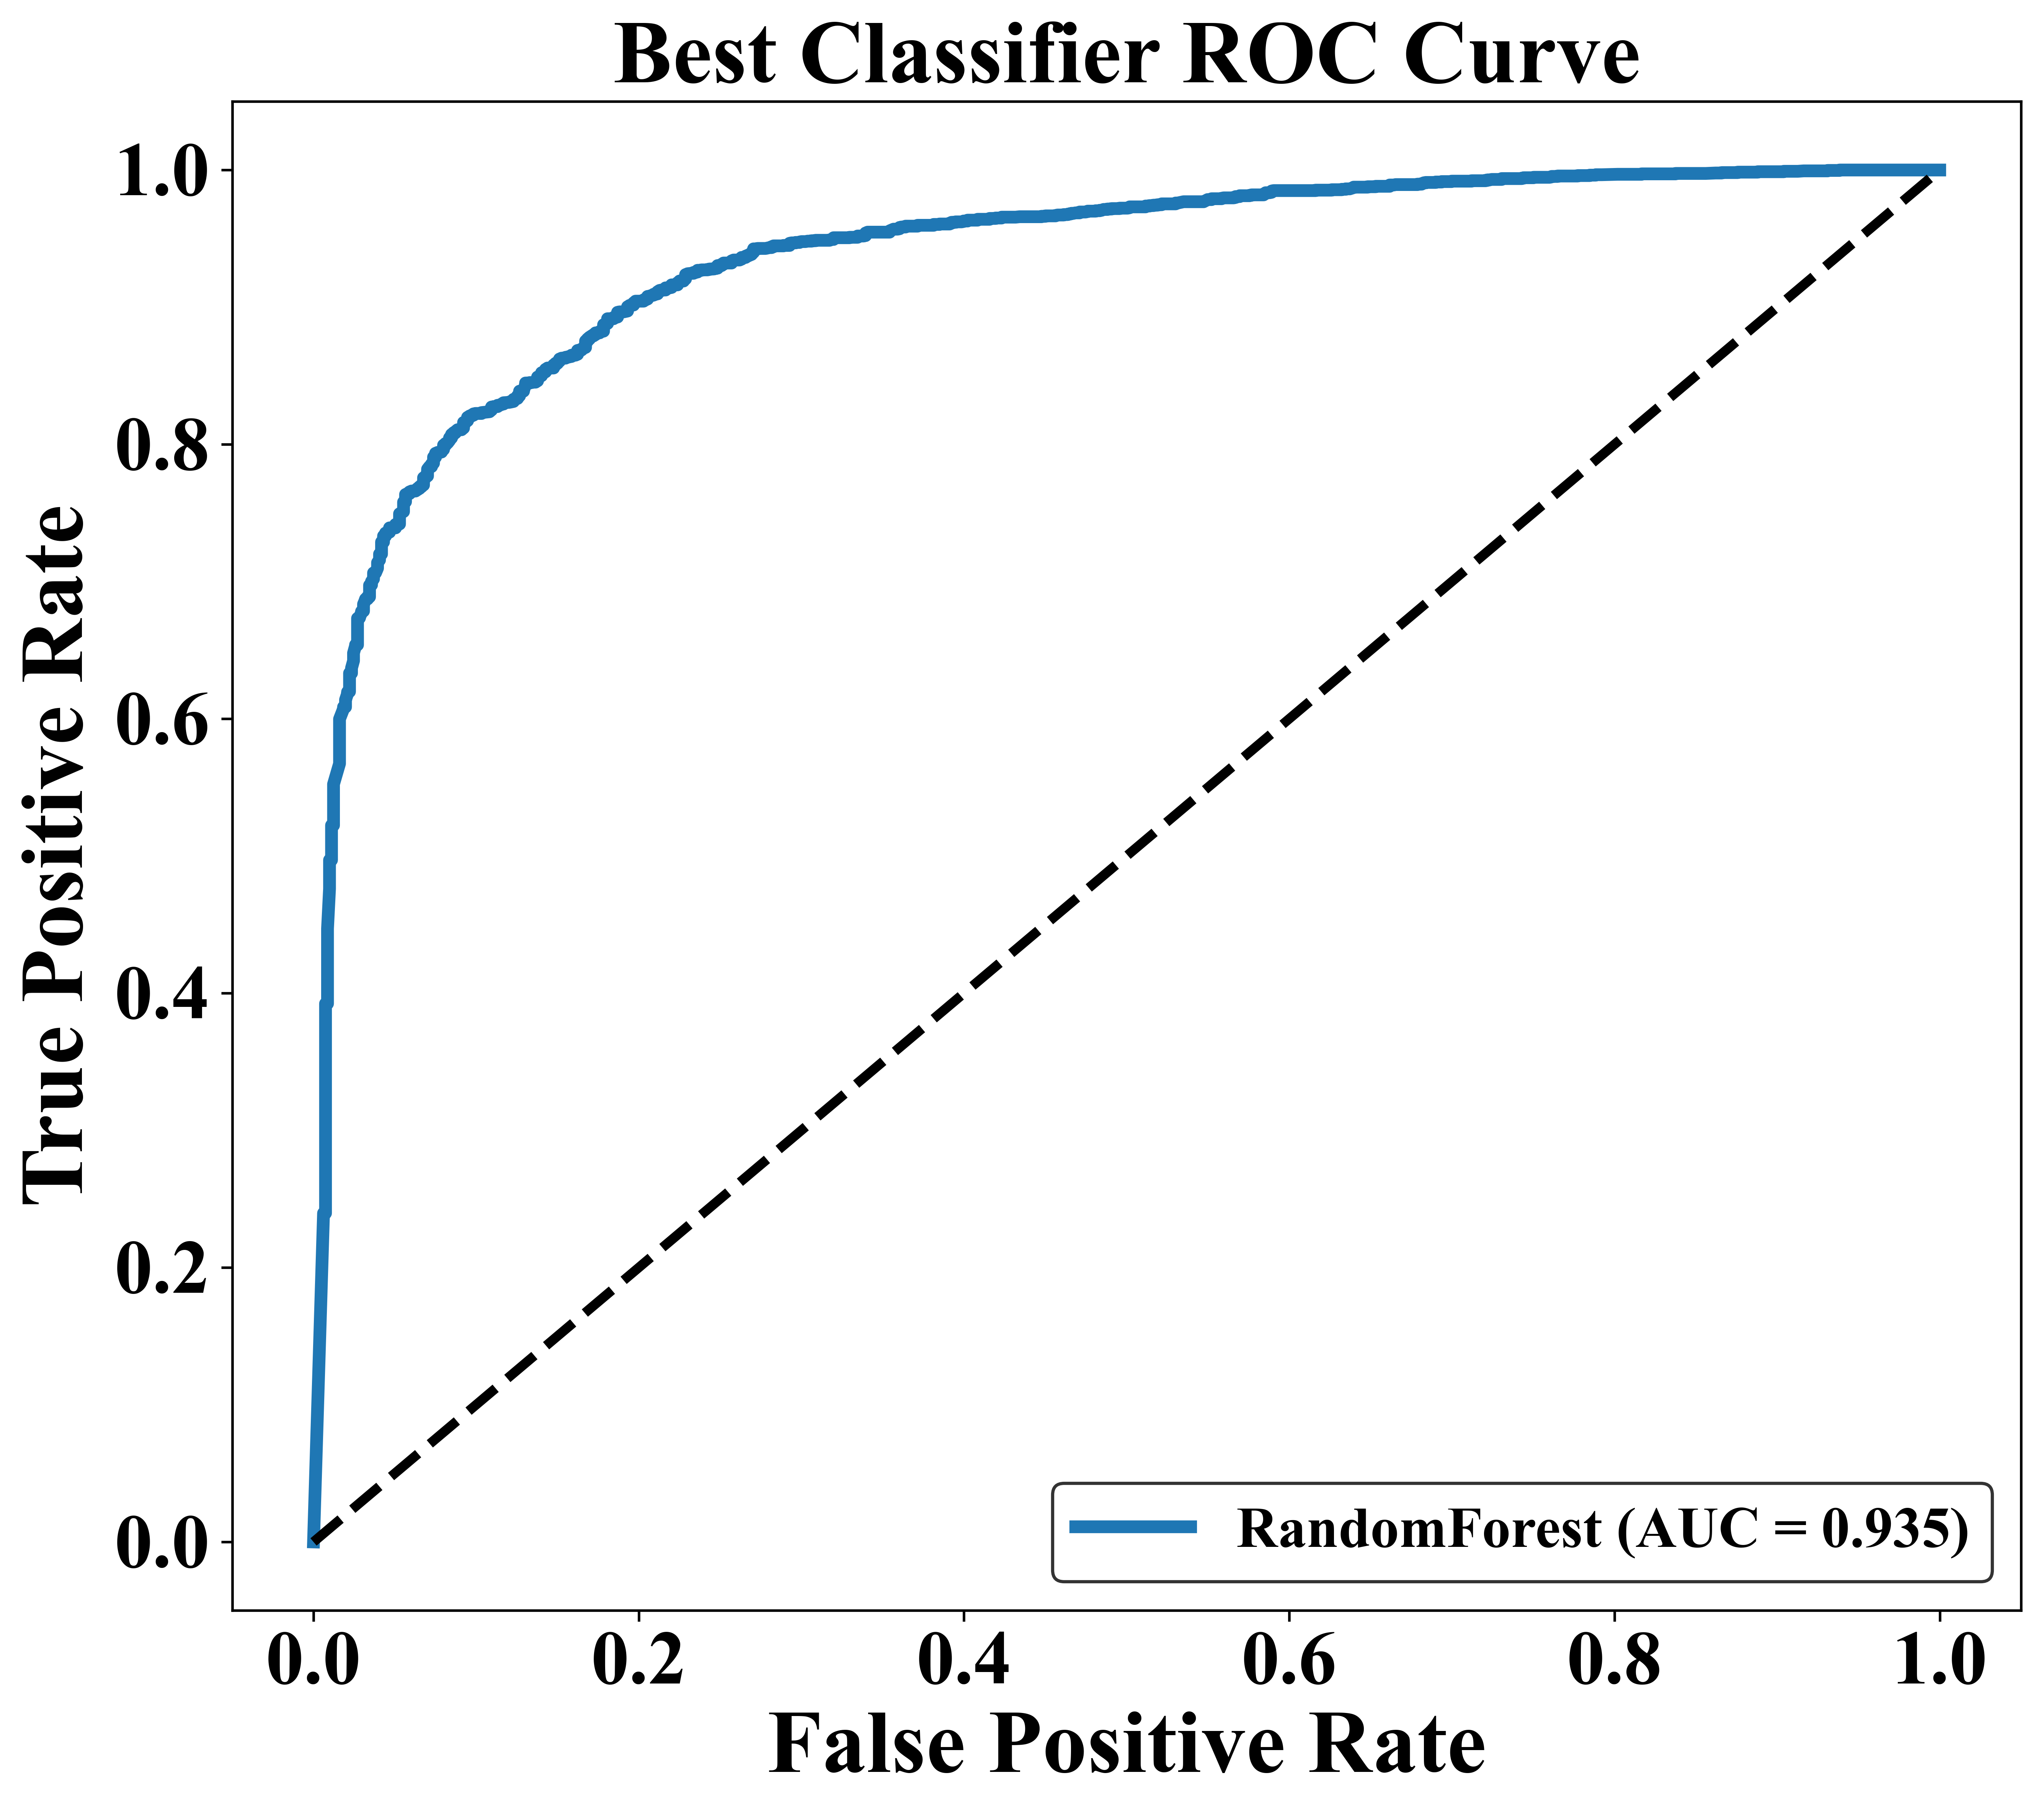

Best classifier: RandomForest
Best ROC-AUC: 0.9349029151022533


In [7]:
# ============================================
# Best Classifier ROC Curve Only
# ============================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.weight"] = "bold"

best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

best_model.fit(X_train, y_train)

y_prob_best = best_model.predict_proba(X_test)[:, 1]

fpr_best, tpr_best, _ = roc_curve(y_test, y_prob_best)
best_auc = auc(fpr_best, tpr_best)

fig, ax = plt.subplots(figsize=(9, 8), dpi=600)

ax.plot(
    fpr_best,
    tpr_best,
    linewidth=4,
    label=f"{best_model_name} (AUC = {best_auc:.3f})"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=3,
    color="black"
)

ax.set_xlabel("False Positive Rate", fontsize=28, fontweight="bold")
ax.set_ylabel("True Positive Rate", fontsize=28, fontweight="bold")
ax.set_title("Best Classifier ROC Curve", fontsize=28, fontweight="bold")

ax.tick_params(axis="both", labelsize=24)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight("bold")

ax.legend(
    fontsize=18,
    loc="lower right",
    frameon=True,
    edgecolor="black"
)

ax.grid(False)

plt.tight_layout()

plt.savefig("Best_Classifier_ROC_Curve.tiff", dpi=600, bbox_inches="tight")
plt.show()

print("Best classifier:", best_model_name)
print("Best ROC-AUC:", best_auc)

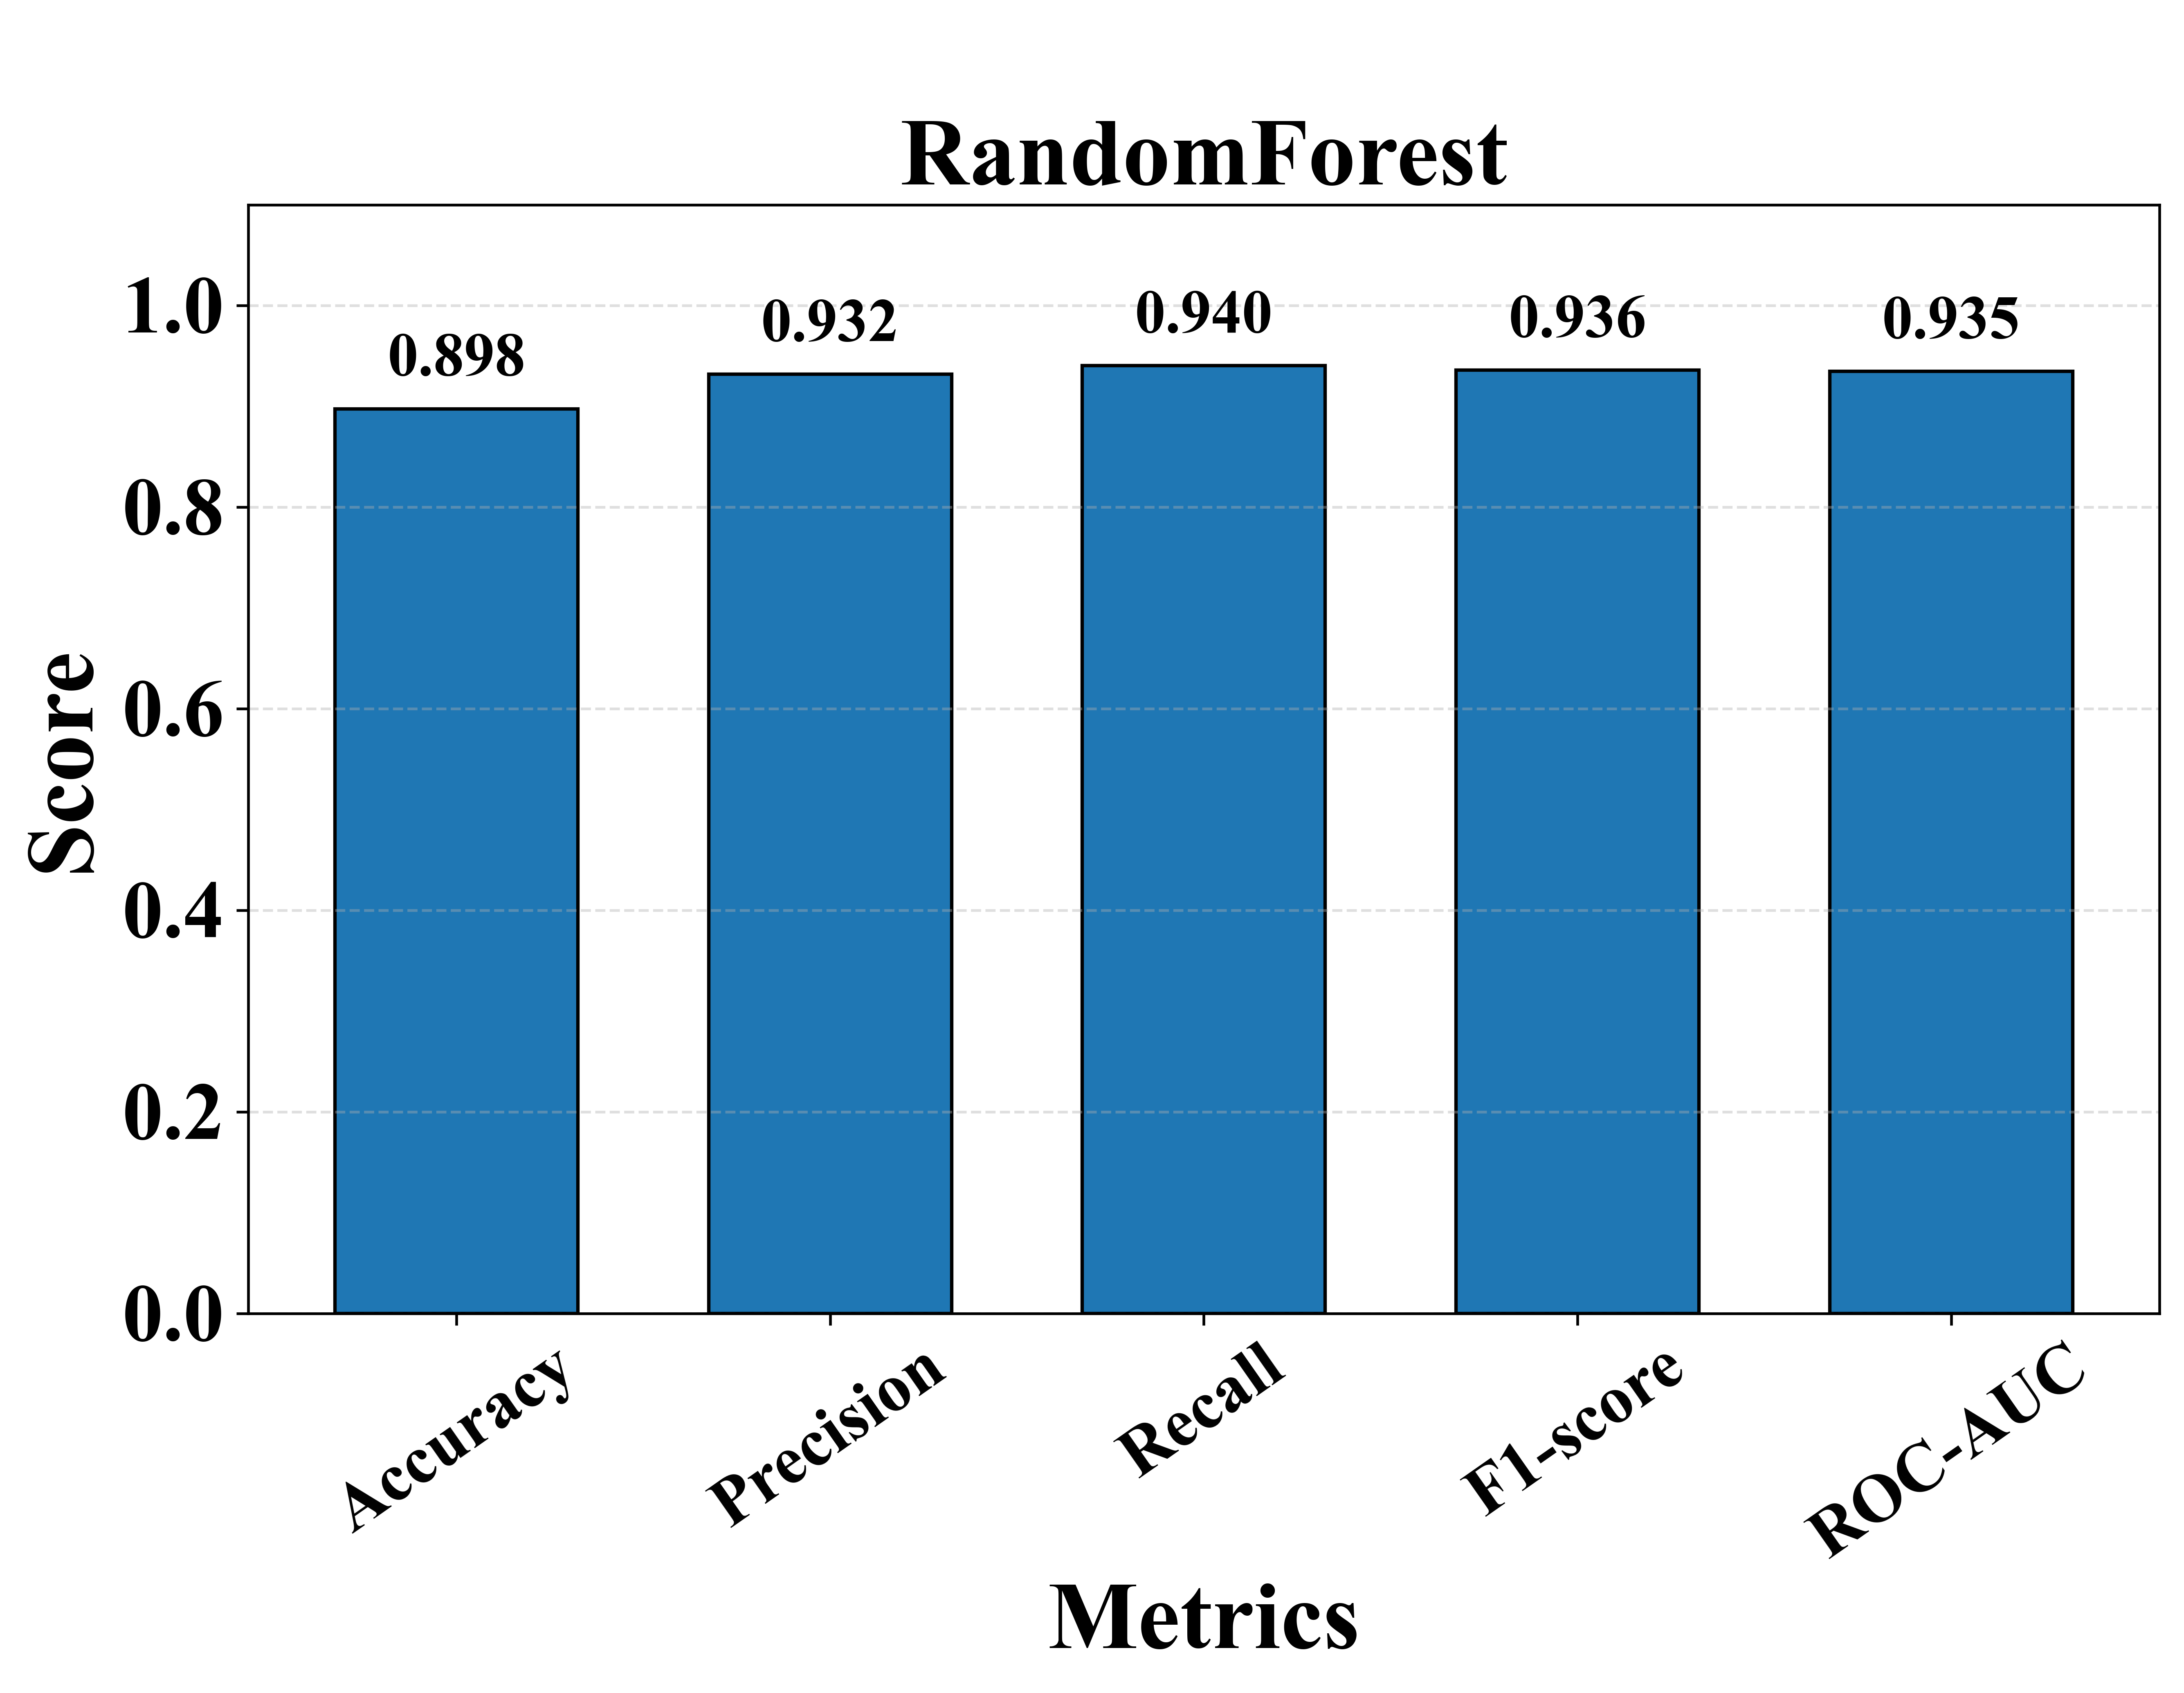

Saved:
Best_Classifier_ROC_Curve.png / .tiff
Best_Classifier_Metrics_BarPlot.png / .tiff
Best_Classifier_Metrics.csv


In [8]:
# ============================================
# Best Classifier Metrics Only
# ============================================

best_metrics = results_df.iloc[0]

metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC"
]

metric_values = best_metrics[metric_names].astype(float).values

fig, ax = plt.subplots(figsize=(9, 7), dpi=600)

bars = ax.bar(
    metric_names,
    metric_values,
    width=0.65,
    edgecolor="black"
)

ax.set_ylabel("Score", fontsize=28, fontweight="bold")
ax.set_xlabel("Metrics", fontsize=28, fontweight="bold")
ax.set_title(
    f"\n{best_model_name}",
    fontsize=28,
    fontweight="bold"
)

ax.set_ylim(0, 1.10)

ax.tick_params(axis="x", labelsize=20, rotation=35)
ax.tick_params(axis="y", labelsize=24)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight("bold")

for bar, value in zip(bars, metric_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=18,
        fontweight="bold"
    )

ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("Best_Classifier_Metrics_BarPlot.png", dpi=600, bbox_inches="tight")
plt.savefig("Best_Classifier_Metrics_BarPlot.tiff", dpi=600, bbox_inches="tight")
plt.show()

best_metrics.to_csv("Best_Classifier_Metrics.csv")

print("Saved:")
print("Best_Classifier_ROC_Curve.png / .tiff")
print("Best_Classifier_Metrics_BarPlot.png / .tiff")
print("Best_Classifier_Metrics.csv")

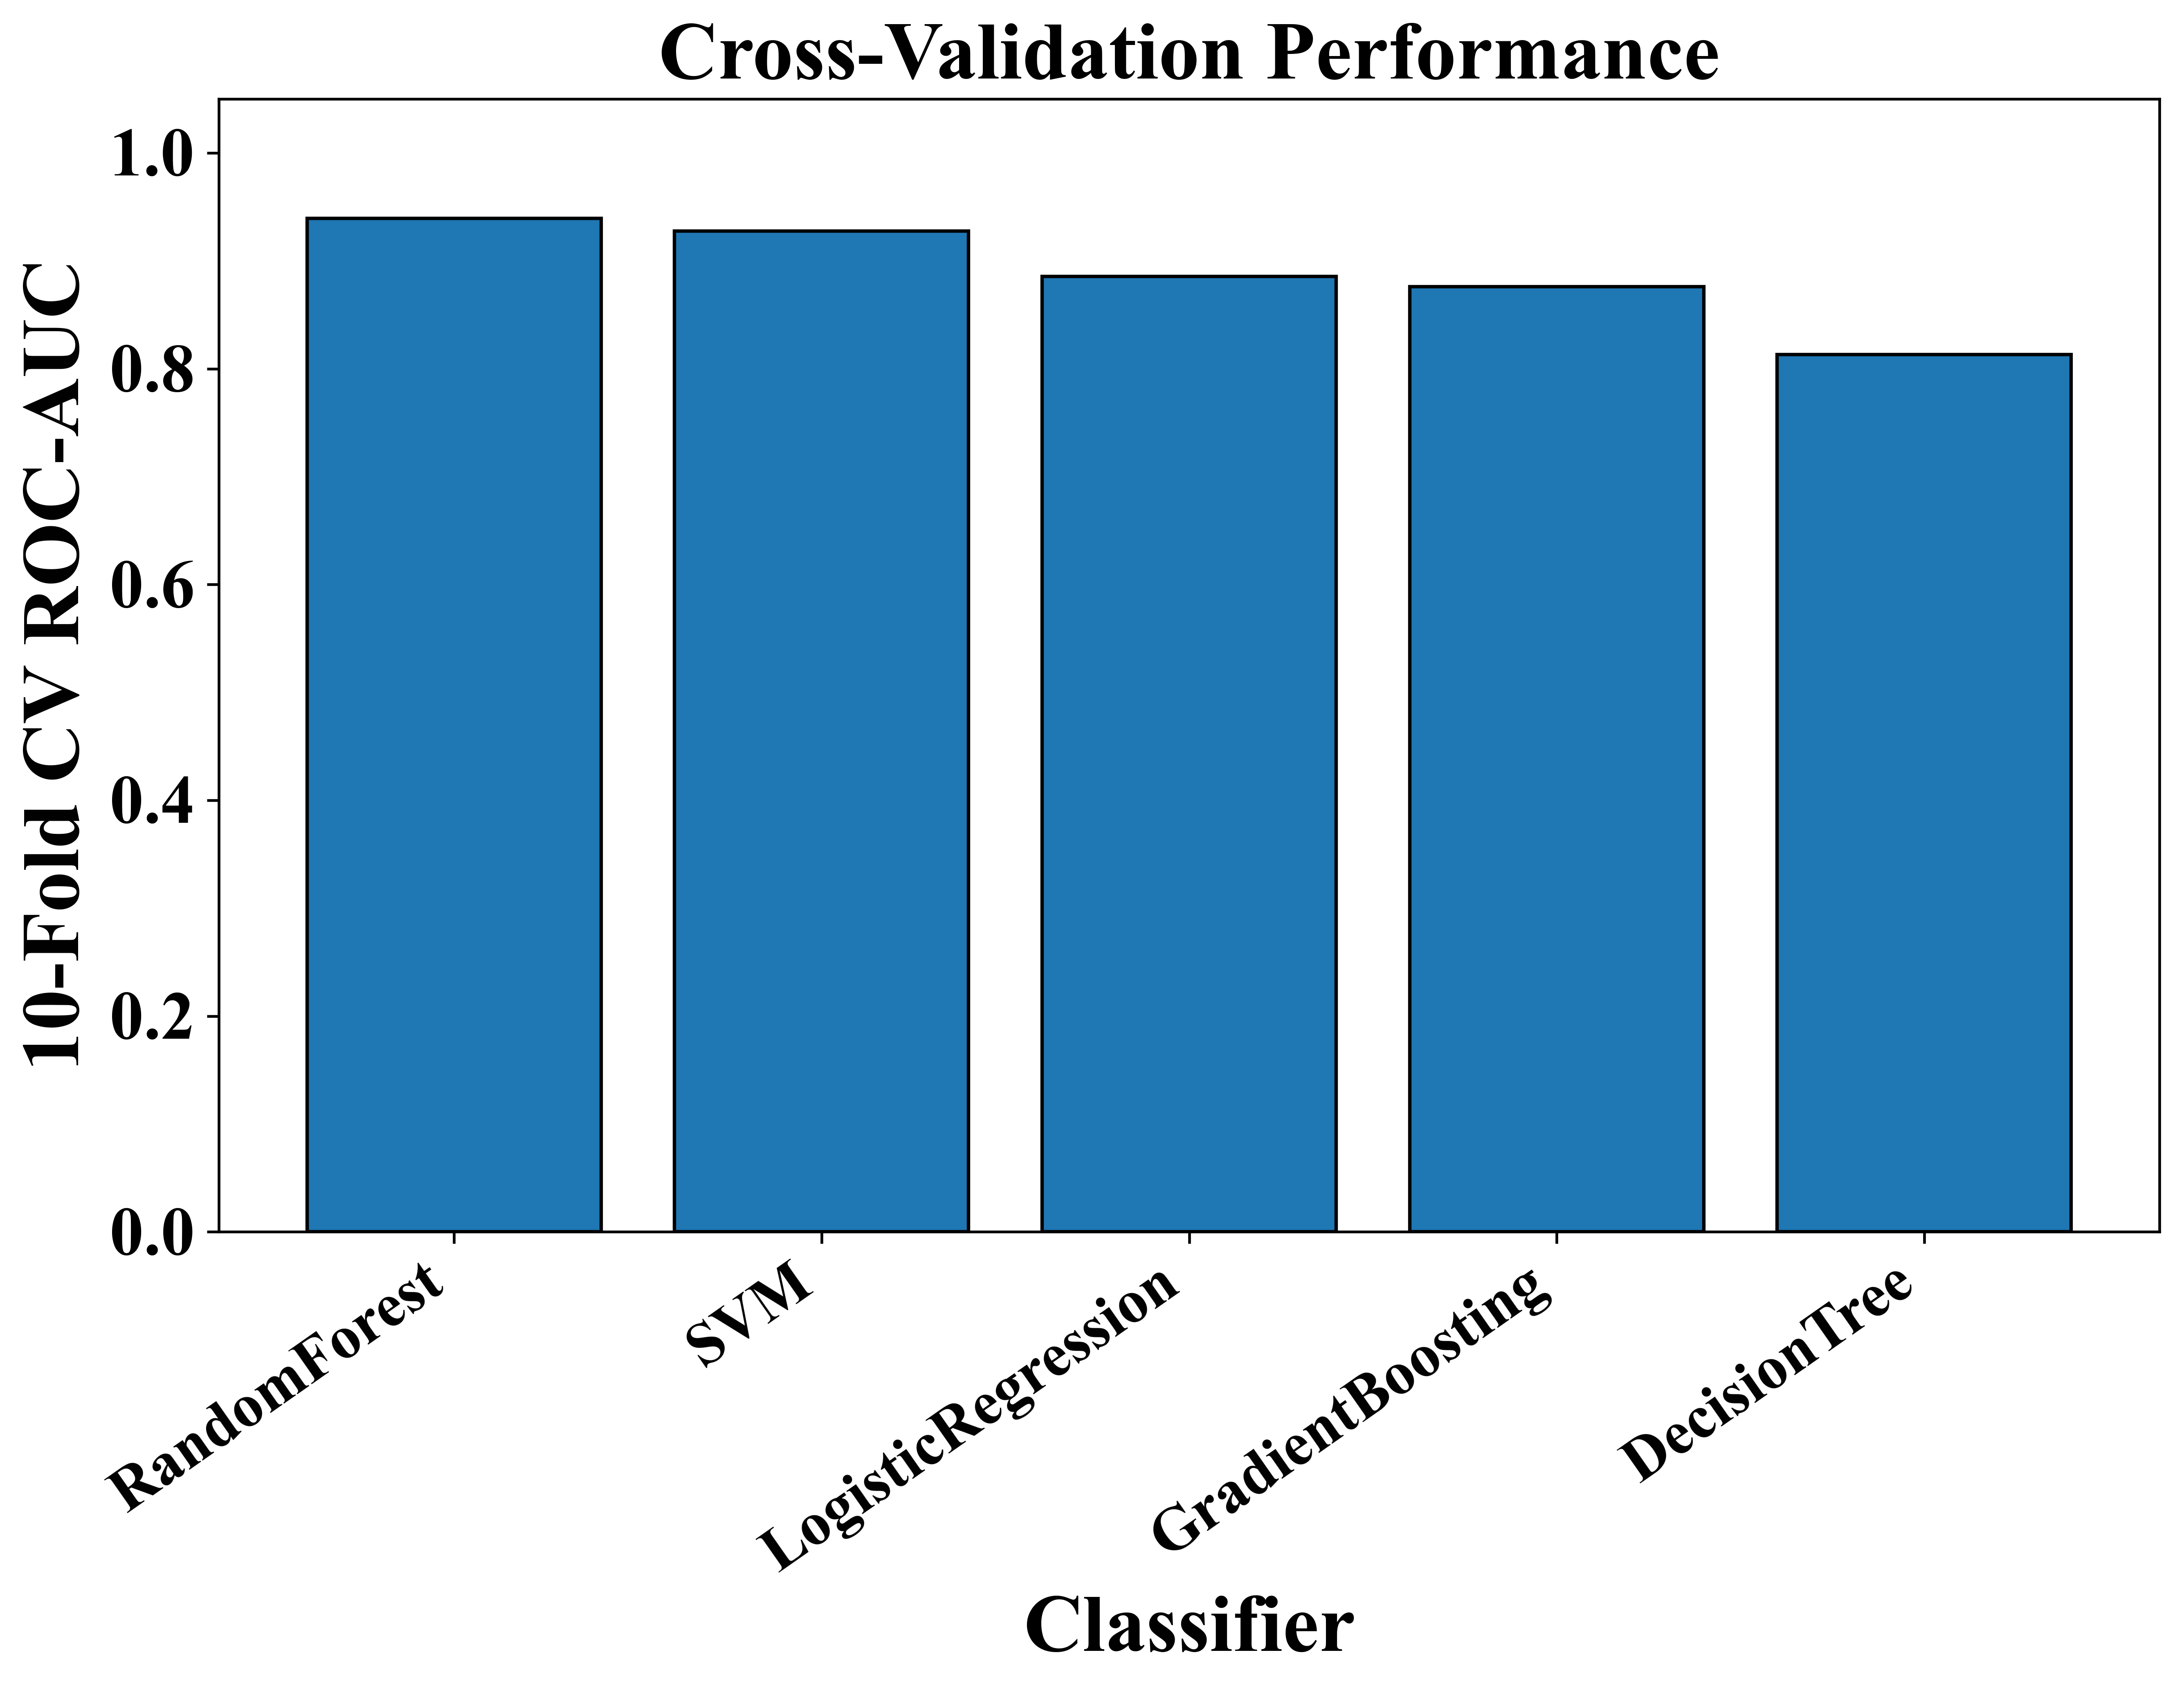

In [5]:
cv_plot = results_df.set_index("Model")["10Fold_CV_ROC_AUC_Mean"]

fig, ax = plt.subplots(figsize=(9,7), dpi=600)

bars = ax.bar(cv_plot.index, cv_plot.values, edgecolor="black")

ax.set_ylabel("10-Fold CV ROC-AUC", fontsize=24, fontweight="bold")
ax.set_xlabel("Classifier", fontsize=24, fontweight="bold")
ax.set_title("Cross-Validation Performance", fontsize=24, fontweight="bold")

plt.xticks(rotation=35, ha="right", fontsize=18, fontweight="bold")
plt.yticks(fontsize=20, fontweight="bold")
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("CrossValidation_ROCAUC.png", dpi=600, bbox_inches="tight")
plt.savefig("CrossValidation_ROCAUC.tiff", dpi=600, bbox_inches="tight")
plt.show()

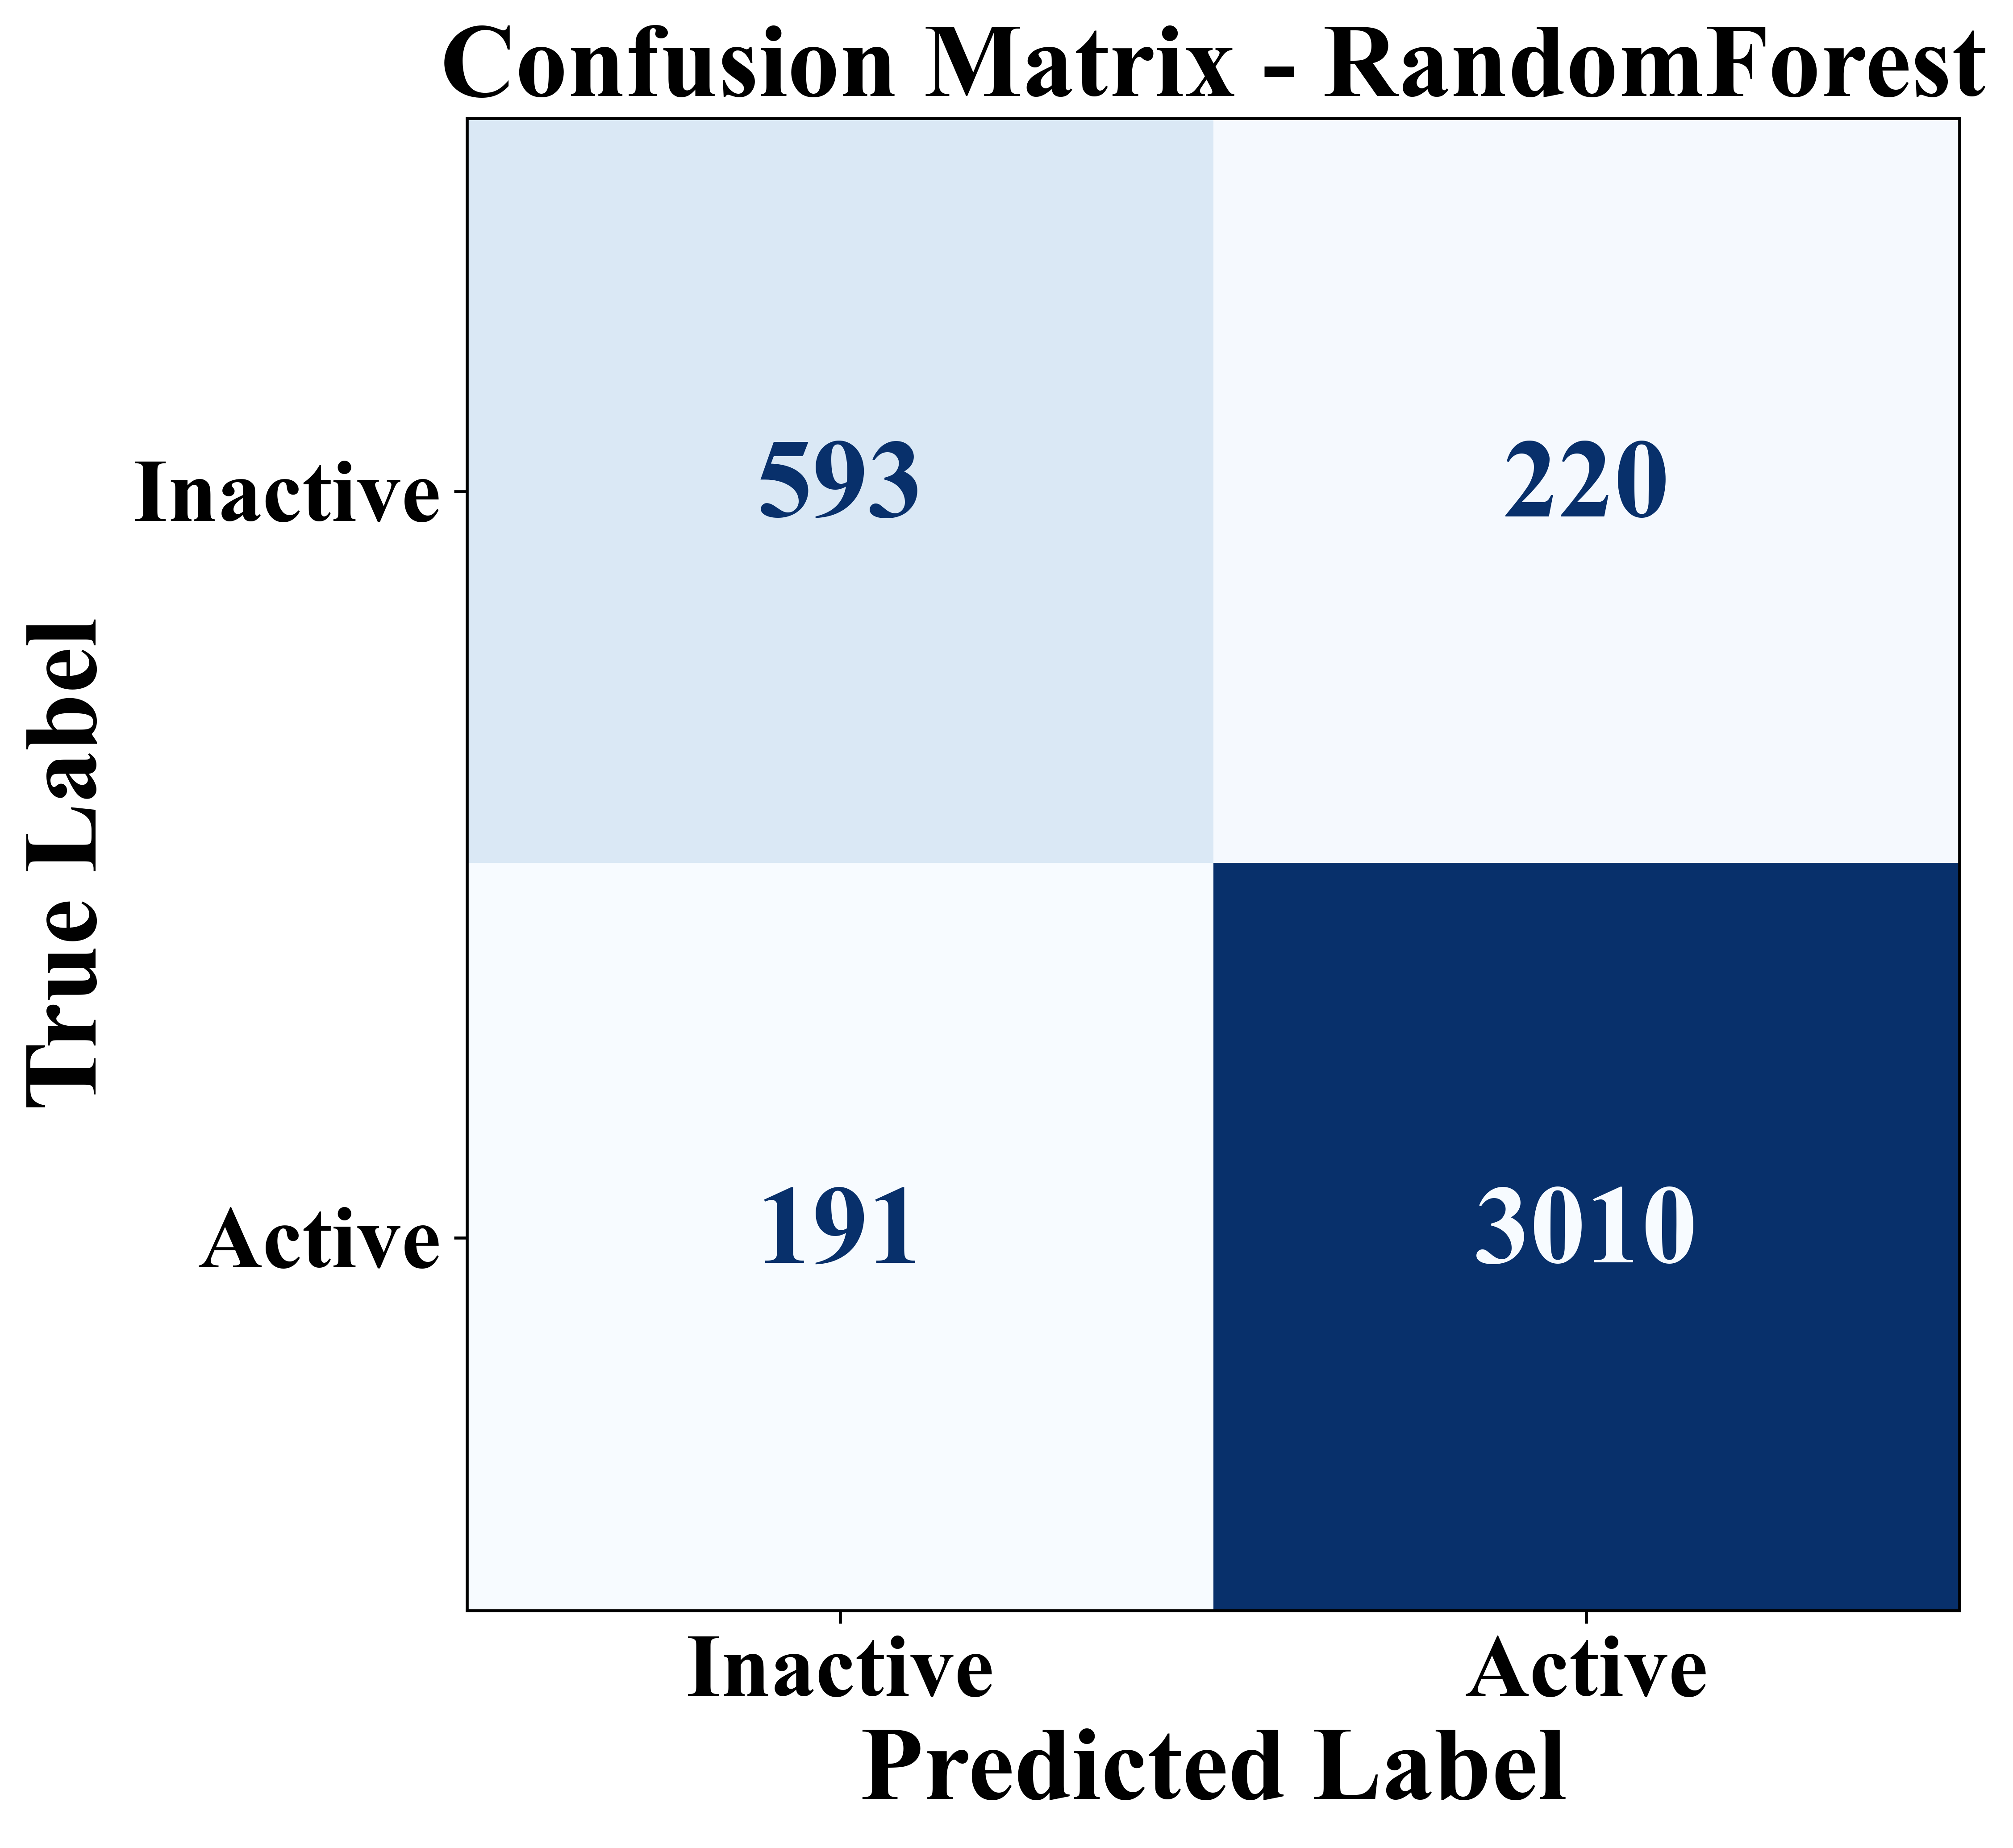

Saved:
Best_Classifier_Confusion_Matrix.png
Best_Classifier_Confusion_Matrix.tiff
Best classifier: RandomForest


In [17]:
# ============================================
# Best Classifier Confusion Matrix
# ============================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.weight"] = "bold"

# Select best classifier based on ROC-AUC
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

# Train best model again
best_model.fit(X_train, y_train)

# Predict
y_pred_best = best_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(8, 7), dpi=600)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Inactive", "Active"]
)

disp.plot(
    ax=ax,
    cmap="Blues",
    colorbar=False,
    values_format="d"
)

ax.set_title(
    f"Confusion Matrix - {best_model_name}",
    fontsize=28,
    fontweight="bold"
)

ax.set_xlabel("Predicted Label", fontsize=28, fontweight="bold")
ax.set_ylabel("True Label", fontsize=28, fontweight="bold")

ax.tick_params(axis="both", labelsize=24)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight("bold")

for text in ax.texts:
    text.set_fontsize(30)
    text.set_fontweight("bold")
    text.set_fontfamily("Times New Roman")

plt.tight_layout()

plt.savefig("Best_Classifier_Confusion_Matrix.png", dpi=600, bbox_inches="tight")
plt.savefig("Best_Classifier_Confusion_Matrix.tiff", dpi=600, bbox_inches="tight")

plt.show()

print("Saved:")
print("Best_Classifier_Confusion_Matrix.png")
print("Best_Classifier_Confusion_Matrix.tiff")
print("Best classifier:", best_model_name)